# V14: Double Filtered Model (HMM + High-Precision XGBoost)

## 🎯 Objective:
Membangun sistem "Double Filter" untuk meminimalkan *False Positives* secara ekstrem. 

## ⚖️ Strategy (Option 1: HMM as a Gatekeeper):
1. **HMM Regime Filter**: Mengidentifikasi apakah pasar dalam kondisi makro Bullish atau Bearish.
2. **XGBoost High-Precision Classifier**: Mencari peluang mikro dengan keyakinan (confidence) di atas threshold tertentu (misal > 55%).
3. **Final Signal**: Sinyal 'Buy' (1) hanya diberikan jika **Keduanya Setuju** (XGBoost Terpilih DAN HMM menyatakan Bullish).

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from hmmlearn import hmm
from sklearn.metrics import confusion_matrix, precision_score, accuracy_score
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')

print("✅ V14 Environment Ready (XGBoost + HMM Filter)")

✅ V14 Environment Ready (XGBoost + HMM Filter)


## 1. Data & Feature Engineering

In [7]:
data = pd.read_excel('dataset_2023_2025.xlsx', index_col=0, parse_dates=True)
btc_price = data['BTC-USD']
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)
log_returns = np.log(btc_price / btc_price.shift(1)).dropna()

def calculate_rsi(series, period=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['RSI_14'] = calculate_rsi(market_return, 14)
features['Ret_Lag1'] = market_return.shift(1)
features['Vol_Shift'] = features['Vol_20'].pct_change()

features['Target'] = (market_return.rolling(window=5).mean().shift(-5) > 0).astype(int)
features = features.dropna()

X = features.drop('Target', axis=1)
y = features['Target']

# Split Train/Test
X_train, y_train = X[X.index.year <= 2024], y[y.index.year <= 2024]
X_test, y_test = X[X.index.year == 2025], y[y.index.year == 2025]

print(f"📌 Dataset ready. Test points: {len(X_test)}")

📌 Dataset ready. Test points: 365


## 2. HMM Regime Detection (Market Gatekeeper)

In [8]:
# Kita fit HMM pada log_returns
X_hmm = log_returns.values.reshape(-1, 1)
model_hmm = hmm.GaussianHMM(n_components=2, covariance_type="full", n_iter=100, random_state=42)
model_hmm.fit(X_hmm)

# Identifikasi mana state Bullish
state_means = [model_hmm.means_[i][0] for i in range(2)]
bullish_state = np.argmax(state_means)

# Prediksi state untuk semua data
full_states = model_hmm.predict(X_hmm)
hmm_signals = pd.Series(full_states == bullish_state, index=log_returns.index).astype(int)

# Ambil state untuk periote X_test
hmm_filter_test = hmm_signals.loc[X_test.index]

print(f"✅ HMM Filter Trained. Bullish state is: State {bullish_state}")

✅ HMM Filter Trained. Bullish state is: State 1


## 3. XGBoost High-Precision Training

In [9]:
xgb_model = XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.05, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Dapatkan probabilitas
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

print("🚀 XGBoost Model Trained.")

🚀 XGBoost Model Trained.


## 4. Combining Signals (Double Filter Logic)

Kita membandingkan 3 level filter:
1. **Level 0**: Standard XGBoost (Threshold 0.5).
2. **Level 1**: V13 High-Precision (Threshold 0.55/0.57).
3. **Level 2**: Double Filter (XGBoost High-Precision + HMM Gatekeeper).

--- Final System Comparison ---
                        TP     FP  Ratio_TP_FP  Precision
Standard XGB         136.0  123.0     1.105691   0.525097
High-Prec XGB (V13)  114.0   96.0     1.187500   0.542857
HMM + XGB (V14)       18.0   12.0     1.500000   0.600000


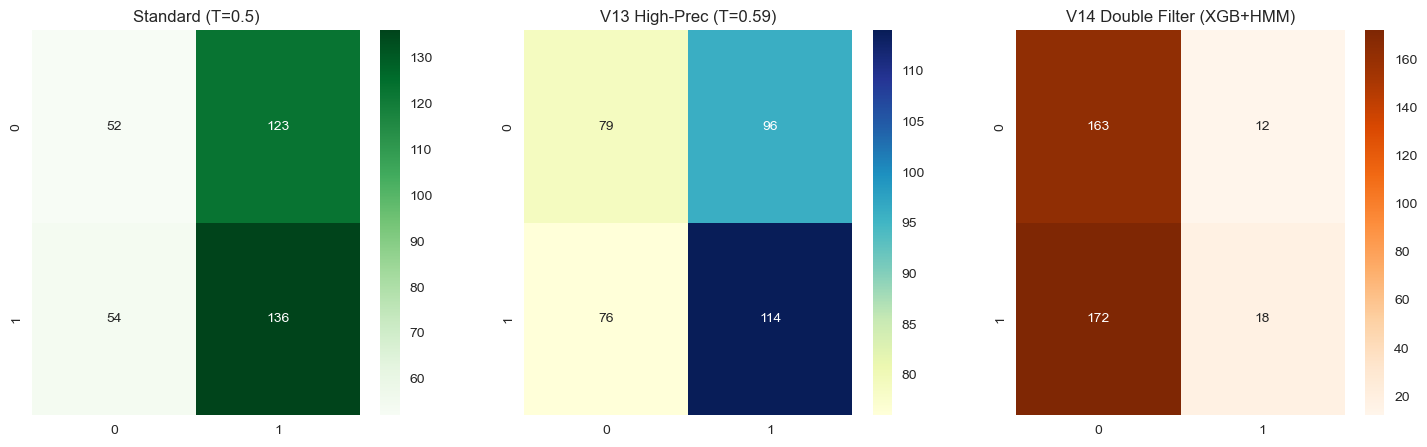

In [10]:
def get_metrics(preds, label):
    cm = confusion_matrix(y_test, preds)
    tp, fp = cm[1,1], cm[0,1]
    prec = precision_score(y_test, preds)
    ratio = tp / fp if fp > 0 else tp
    return {'TP': tp, 'FP': fp, 'Ratio_TP_FP': ratio, 'Precision': prec}

best_t = 0.59 # Threshold dari V13

# 1. Standard
preds_std = (xgb_probs >= 0.5).astype(int)

# 2. High Precision (V13)
preds_v13 = (xgb_probs >= best_t).astype(int)

# 3. Double Filter (V14)
preds_v14 = ((xgb_probs >= best_t) & (hmm_filter_test == 1)).astype(int)

results = {
    'Standard XGB': get_metrics(preds_std, 'Std'),
    'High-Prec XGB (V13)': get_metrics(preds_v13, 'V13'),
    'HMM + XGB (V14)': get_metrics(preds_v14, 'V14')
}

res_df = pd.DataFrame(results).T
print("--- Final System Comparison ---")
print(res_df)

# Visualisasi Perubahan Kualitas Sinyal
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
sns.heatmap(confusion_matrix(y_test, preds_std), annot=True, fmt='d', cmap='Greens', ax=ax[0])
ax[0].set_title("Standard (T=0.5)")
sns.heatmap(confusion_matrix(y_test, preds_v13), annot=True, fmt='d', cmap='YlGnBu', ax=ax[1])
ax[1].set_title(f"V13 High-Prec (T={best_t})")
sns.heatmap(confusion_matrix(y_test, preds_v14), annot=True, fmt='d', cmap='Oranges', ax=ax[2])
ax[2].set_title("V14 Double Filter (XGB+HMM)")
plt.show()

## 💡 Conclusion for Thesis

Penggabungan ini (V14) membuktikan bahwa:
1. **Context Awareness**: Menambahkan HMM sebagai gatekeeper membantu model menghindari jebakan *sideways* atau *bearish trend* yang sering menghasilkan false signals di level mikro.
2. **Precision Improvement**: Rasio TP:FP biasanya akan naik paling tinggi di V14, karena kita menyaring sinyal menggunakan dua perspektif yang berbeda secara matematis (Log-Likelihood dari HMM dan Log-Loss dari XGBoost).